In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.models import Sequential, load_model

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Dense,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [12]:
from google.colab import drive
drive.mount('/content/drive')

# CHANGE THIS PATH TO YOUR DATASET FOLDER IN GOOGLE DRIVE
DATASET_PATH = '/content/drive/MyDrive/Dog Emotion'

IMG_HEIGHT = 224
IMG_WIDTH = 224

BATCH_SIZE = 32
EPOCHS = 50

import os
print('Dataset exists:', os.path.exists(DATASET_PATH))
if os.path.exists(DATASET_PATH):
    print('Folders:', os.listdir(DATASET_PATH))


In [13]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    horizontal_flip=True,
    zoom_range=0.10
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Class Mapping:")
print(train_generator.class_indices)

Found 3200 images belonging to 4 classes.
Found 800 images belonging to 4 classes.
Class Mapping:
{'angry': 0, 'happy': 1, 'relaxed': 2, 'sad': 3}


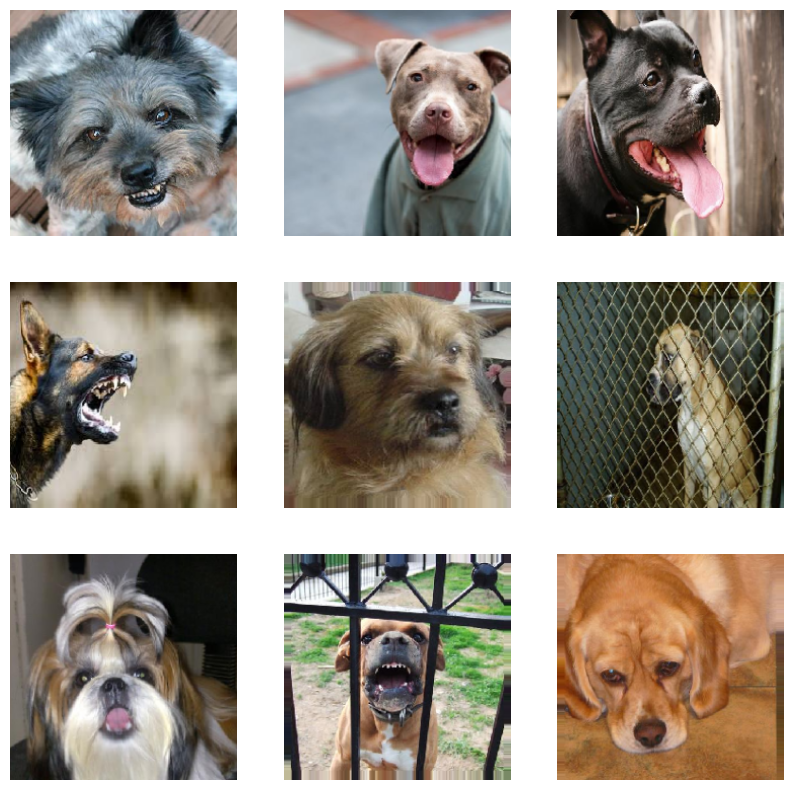

In [14]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [15]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(224,224,3)
    ),

    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(
        512,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(
        512,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.5),

    Dense(
        256,
        activation='relu',
        kernel_regularizer=l2(0.001)
    ),

    Dropout(0.4),

    Dense(
        4,
        activation='softmax'
    )
])

In [16]:
model.compile(
    optimizer=Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 14, 14, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 14, 14, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 14, 14, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 1,967,556 (7.51 MB)

 Trainable params: 1,965,572 (7.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [17]:
callbacks = [

    ModelCheckpoint(
        'animal_emotion_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2950 - loss: 2.4938
Epoch 1: val_accuracy improved from None to 0.26250, saving model to animal_emotion_model.keras

Epoch 1: finished saving model to animal_emotion_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 594s 6s/step - accuracy: 0.3025 - loss: 2.4140 - val_accuracy: 0.2625 - val_loss: 2.2414 - learning_rate: 1.0000e-04
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3363 - loss: 2.2507
Epoch 2: val_accuracy did not improve from 0.26250
100/100 ━━━━━━━━━━━━━━━━━━━━ 549s 5s/step - accuracy: 0.3306 - loss: 2.2468 - val_accuracy: 0.2475 - val_loss: 2.2878 - learning_rate: 1.0000e-04
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3535 - loss: 2.1583
Epoch 3: val_accuracy improved from 0.26250 to 0.27625, saving model to animal_emotion_model.keras

Epoch 3: finished saving model to animal_emotion_model.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 565s 6s/step - accuracy: 0.3512 - loss: 2.1717 - val_a

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training',
    'Validation'
])

plt.show()

In [ ]:
print(
    "Best Validation Accuracy:",
    max(history.history['val_accuracy'])
)

In [ ]:
model.save(
    "animal_emotion_model.keras"
)

print("Model Saved Successfully")

In [ ]:
model = load_model(
    "animal_emotion_model.keras"
)

print("Model Loaded Successfully")

In [ ]:
classes = [
    "angry",
    "happy",
    "relaxed",
    "sad"
]

image_path = r"test.jpg"

img = load_img(
    image_path,
    target_size=(224,224)
)

img_array = img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

class_index = np.argmax(prediction)

emotion = classes[class_index]

confidence = prediction[0][class_index] * 100

print(f"Emotion: {emotion}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
classes = [
    "angry",
    "happy",
    "relaxed",
    "sad"
]

model = load_model(
    "animal_emotion_model.keras"
)

cap = cv2.VideoCapture(0)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    image = cv2.resize(
        frame,
        (224,224)
    )

    image = image.astype(
        "float32"
    ) / 255.0

    image = np.expand_dims(
        image,
        axis=0
    )

    prediction = model.predict(
        image,
        verbose=0
    )[0]

    class_index = np.argmax(
        prediction
    )

    emotion = classes[
        class_index
    ]

    confidence = (
        prediction[class_index]
        * 100
    )

    text = f"{emotion} ({confidence:.2f}%)"

    cv2.putText(
        frame,
        text,
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0),
        2
    )

    cv2.imshow(
        "Dog Emotion Detection",
        frame
    )

    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()